In [8]:
from helpers import *
import numpy as np
import matplotlib.pyplot as plt

## Soft X-rays

In [9]:
params = np.load("sxr_LoS_params.npy")

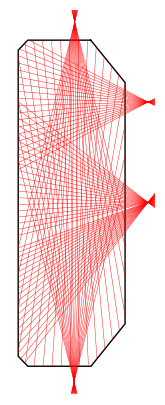

In [10]:
# plot ground truth, superposing the sxr LoS
from matplotlib.path import Path
from matplotlib.patches import PathPatch

patch = tomo_plots.plot_profile(np.ones((120,41)), levels=12, figsize=(3.5, 5), tcv_plot_clip=True, ax=None, cmap="gray", vmax=1, vmin=0)

# Variant patches: same vessel outline as `patch`, but with one side opened up
# so specific LoS groups aren't clipped where they're meant to extend past the vessel.
_v0 = patch.get_path().vertices
_codes = patch.get_path().codes
_x_max, _y_max, _y_min = _v0[:, 0].max(), _v0[:, 1].max(), _v0[:, 1].min()

# patch1: top opened (i<20, top vertical fan)
_v = _v0.copy()
_v[_v[:, 1] > _y_max - 10, 1] = 300
patch1 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch1)

# patch2: right opened (60<=i<80, horizontal fan extending past the outer wall)
_v = _v0.copy()
_v[_v[:, 0] > _x_max - 10, 0] = 300
patch2 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch2)

# patch3: bottom opened (80<=i<100, divertor fan extending below the vessel)
_v = _v0.copy()
_v[_v[:, 1] < _y_min + 10, 1] = -300
patch3 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch3)

r_vert = np.linspace(0., 40.4, 4000)
r_horiz = np.linspace(0., 52.4, 4000)
r_div = np.linspace(0., 47.4, 4000)
center = np.array([120, 41], dtype=int) / 2
Lr, Lz = 0.511, 1.5
h = Lz / 120
for i in range(params.shape[0]):
    if np.isclose(np.tan(params[i, 1]), 0, atol=1e-6):
        lc = plt.vlines(center[1] + params[i, 0], 0, Lz, "r", linewidth=0.3)
        lc.set_clip_path(patch)
    else:
        p = params[i, 0]
        theta = params[i, 1]
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        if i<20:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            lines = plt.plot(r_vert[(y>0.) & (y<130)], y[(y>0.) & (y<130)], "r", linewidth=0.3)
            clip = patch1
        elif i<60:
            y = center[0] + p / h / np.sin(theta) - (r_horiz - center[1]) / np.tan(theta)
            lines = plt.plot(r_horiz[(y>0.4) & (y<119.6)], y[(y>0.4) & (y<119.6)], "r", linewidth=0.3)
            clip = patch2
        elif i<80:
            y = center[0] + p / h / np.sin(theta) - (r_horiz - center[1]) / np.tan(theta)
            lines = plt.plot(r_horiz[:], y[:], "r", linewidth=0.3)
            clip = patch2
        elif i<100:
            y = center[0] + p / h / np.sin(theta) - (r_div - center[1]) / np.tan(theta)
            lines = plt.plot(r_div[ (y>-10.) & (y<119.6)], y[ (y>-10.) & (y<119.6)], "r", linewidth=0.3)
            clip = patch3
        else:
            lines = plt.plot(r_vert, y, "r", linewidth=0.4)
            clip = patch
        for ln in lines:
            ln.set_clip_path(clip)
# plt.xlim([-0.75, 41.75])
# plt.ylim([-0.75, round(Lz / h)+0.75])
plt.xlim([-3, 50])
plt.ylim([-10.5, 130])

plt.savefig('figs/sxr_LoS_configuration.eps', format='eps', bbox_inches="tight")

## DMPX

In [11]:
params = np.load("dmpx_LoS_params.npy")[::2]

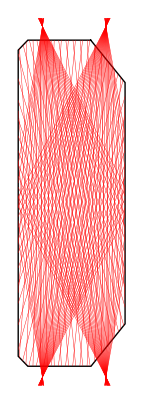

In [12]:
# plot ground truth, superposing the sxr LoS
from matplotlib.path import Path
from matplotlib.patches import PathPatch

patch = tomo_plots.plot_profile(np.ones((120,41)), levels=12, figsize=(3.5, 5), tcv_plot_clip=True, ax=None, cmap="gray", vmax=1, vmin=0)

# Variant patches: same vessel outline as `patch`, but with one side opened up
# so specific LoS groups aren't clipped where they're meant to extend past the vessel.
_v0 = patch.get_path().vertices
_codes = patch.get_path().codes
_x_max, _y_max, _y_min = _v0[:, 0].max(), _v0[:, 1].max(), _v0[:, 1].min()

# patch1: top opened (i<20, top vertical fan)
_v = _v0.copy()
_v[_v[:, 1] > _y_max - 10, 1] = 300
patch1 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch1)

# patch2: right opened (60<=i<80, horizontal fan extending past the outer wall)
_v = _v0.copy()
_v[_v[:, 0] > _x_max - 10, 0] = 300
patch2 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch2)

# patch3: bottom opened (80<=i<100, divertor fan extending below the vessel)
_v = _v0.copy()
_v[_v[:, 1] < _y_min + 10, 1] = -300
patch3 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch3)

r_vert = np.linspace(0., 40.4, 4000)
r_horiz = np.linspace(0., 52.4, 4000)
r_div = np.linspace(0., 47.4, 4000)
center = np.array([120, 41], dtype=int) / 2
Lr, Lz = 0.511, 1.5
h = Lz / 120
for i in range(params.shape[0]):
    if np.isclose(np.tan(params[i, 1]), 0, atol=1e-6):
        lc = plt.vlines(center[1] + params[i, 0], 0, Lz, "r", linewidth=0.3)
        lc.set_clip_path(patch)
    else:
        p = params[i, 0]
        theta = params[i, 1]
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        if i<64:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            lines = plt.plot(r_vert[(y>0.) & (y<127)], y[(y>0.) & (y<127)], "r", linewidth=0.3)
            clip = patch1
        elif i<128:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            lines = plt.plot(r_vert[ (y>-7.) & (y<119.6)], y[ (y>-7.) & (y<119.6)], "r", linewidth=0.3)
            clip = patch3
        else:
            lines = plt.plot(r_vert, y, "r", linewidth=0.4)
            clip = patch
        for ln in lines:
            ln.set_clip_path(clip)
# plt.xlim([-0.75, 41.75])
# plt.ylim([-0.75, round(Lz / h)+0.75])
plt.xlim([-3, 50])
plt.ylim([-10.5, 130])

plt.savefig('figs/dmpx_LoS_configuration.eps', format='eps', bbox_inches="tight")

## Pilatus

In [13]:
params = np.load("pilatus_LoS_params.npy")[::2]

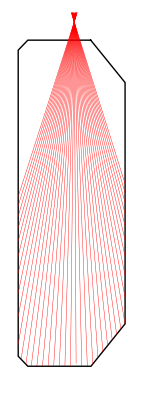

In [14]:
# plot ground truth, superposing the sxr LoS
from matplotlib.path import Path
from matplotlib.patches import PathPatch

patch = tomo_plots.plot_profile(np.ones((120,41)), levels=12, figsize=(3.5, 5), tcv_plot_clip=True, ax=None, cmap="gray", vmax=1, vmin=0)

# Variant patches: same vessel outline as `patch`, but with one side opened up
# so specific LoS groups aren't clipped where they're meant to extend past the vessel.
_v0 = patch.get_path().vertices
_codes = patch.get_path().codes
_x_max, _y_max, _y_min = _v0[:, 0].max(), _v0[:, 1].max(), _v0[:, 1].min()

# patch1: top opened (i<20, top vertical fan)
_v = _v0.copy()
_v[_v[:, 1] > _y_max - 10, 1] = 300
patch1 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch1)

# patch2: right opened (60<=i<80, horizontal fan extending past the outer wall)
_v = _v0.copy()
_v[_v[:, 0] > _x_max - 10, 0] = 300
patch2 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch2)

# patch3: bottom opened (80<=i<100, divertor fan extending below the vessel)
_v = _v0.copy()
_v[_v[:, 1] < _y_min + 10, 1] = -300
patch3 = PathPatch(Path(_v, _codes), facecolor='none', edgecolor='none')
plt.gca().add_patch(patch3)

r_vert = np.linspace(0., 40.4, 4000)
r_horiz = np.linspace(0., 52.4, 4000)
r_div = np.linspace(0., 47.4, 4000)
center = np.array([120, 41], dtype=int) / 2
Lr, Lz = 0.511, 1.5
h = Lz / 120
for i in range(params.shape[0]):
    if np.isclose(np.tan(params[i, 1]), 0, atol=1e-6):
        lc = plt.vlines(center[1] + params[i, 0], 0, Lz, "r", linewidth=0.3)
        lc.set_clip_path(patch)
    else:
        p = params[i, 0]
        theta = params[i, 1]
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        lines = plt.plot(r_vert[(y>0.) & (y<129)], y[(y>0.) & (y<129)], "r", linewidth=0.3)
        clip = patch1
        for ln in lines:
            ln.set_clip_path(clip)
# plt.xlim([-0.75, 41.75])
# plt.ylim([-0.75, round(Lz / h)+0.75])
plt.xlim([-3, 50])
plt.ylim([-10.5, 130])

plt.savefig('figs/pilatus_LoS_configuration.eps', format='eps', bbox_inches="tight")